In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Loading NOAA flood dataset...')
df = pd.read_csv('../data/floods/noaa_floods.csv', low_memory=False)

print(f'Shape: {df.shape}')
print(f'\nFlood types:')
print(df['EVENT_TYPE'].value_counts())
print(f'\nAll columns:')
for i, col in enumerate(df.columns):
    print(f'  {i+1:2}. {col}')
df.head()

Loading NOAA flood dataset...
Shape: (42526, 51)

Flood types:
EVENT_TYPE
Flash Flood        23833
Flood              16963
Coastal Flood       1441
Lakeshore Flood      289
Name: count, dtype: int64

All columns:
   1. BEGIN_YEARMONTH
   2. BEGIN_DAY
   3. BEGIN_TIME
   4. END_YEARMONTH
   5. END_DAY
   6. END_TIME
   7. EPISODE_ID
   8. EVENT_ID
   9. STATE
  10. STATE_FIPS
  11. YEAR
  12. MONTH_NAME
  13. EVENT_TYPE
  14. CZ_TYPE
  15. CZ_FIPS
  16. CZ_NAME
  17. WFO
  18. BEGIN_DATE_TIME
  19. CZ_TIMEZONE
  20. END_DATE_TIME
  21. INJURIES_DIRECT
  22. INJURIES_INDIRECT
  23. DEATHS_DIRECT
  24. DEATHS_INDIRECT
  25. DAMAGE_PROPERTY
  26. DAMAGE_CROPS
  27. SOURCE
  28. MAGNITUDE
  29. MAGNITUDE_TYPE
  30. FLOOD_CAUSE
  31. CATEGORY
  32. TOR_F_SCALE
  33. TOR_LENGTH
  34. TOR_WIDTH
  35. TOR_OTHER_WFO
  36. TOR_OTHER_CZ_STATE
  37. TOR_OTHER_CZ_FIPS
  38. TOR_OTHER_CZ_NAME
  39. BEGIN_RANGE
  40. BEGIN_AZIMUTH
  41. BEGIN_LOCATION
  42. END_RANGE
  43. END_AZIMUTH
  44. END_LOCAT

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,201905,9,1554,201905,9,1830,137295,824116,TEXAS,48,...,3.22,NNE,SAN GERONIMO,29.7898,-98.6406,29.7158,-98.7744,Thunderstorms developed along a cold front as ...,Thunderstorms produced heavy rain that led to ...,CSV
1,201908,1,0,201908,7,1400,141502,849617,SOUTH DAKOTA,46,...,7.62,W,BRUCE,44.5400,-96.9600,44.4300,-96.9400,Minor flooding slowly dwindled during early Au...,"A continuation of flooding from July, the Big ...",CSV
2,201908,1,0,201908,4,700,141502,849620,SOUTH DAKOTA,46,...,2.94,SW,RENNER,43.6900,-96.7600,43.6300,-96.7600,Minor flooding slowly dwindled during early Au...,"A continuation of flooding from July, the Big ...",CSV
3,201908,1,0,201908,5,1500,141502,849618,SOUTH DAKOTA,46,...,13.36,NW,FLANDREAU,44.1700,-96.7800,44.1100,-96.6600,Minor flooding slowly dwindled during early Au...,"A continuation of flooding from July, the Big ...",CSV
4,201908,31,845,201908,31,1130,141946,852096,SOUTH DAKOTA,46,...,0.45,W,WAGNER,43.0821,-98.3182,43.0801,-98.3163,As a weak disturbance acted to focus persisten...,Heavy early morning rainfall resulted in pondi...,CSV


In [2]:
print(f'Total flood records: {len(df):,}')
print(f'\nFlood types:')
print(df['EVENT_TYPE'].value_counts())

print(f'\nTop 10 states:')
print(df['STATE'].value_counts().head(10))

print(f'\nYears covered:')
print(df['YEAR'].value_counts().sort_index())

print(f'\nKey columns check:')
key_cols = ['DEATHS_DIRECT', 'DEATHS_INDIRECT', 'INJURIES_DIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS']
for col in key_cols:
    if col in df.columns:
        print(f'  {col}: {df[col].notna().sum():,} non-null values')

Total flood records: 42,526

Flood types:
EVENT_TYPE
Flash Flood        23833
Flood              16963
Coastal Flood       1441
Lakeshore Flood      289
Name: count, dtype: int64

Top 10 states:
STATE
CALIFORNIA        2872
VIRGINIA          2205
TEXAS             2159
MISSOURI          2122
NEW YORK          1715
KENTUCKY          1623
OHIO              1497
PENNSYLVANIA      1390
ARKANSAS          1351
NORTH CAROLINA    1345
Name: count, dtype: int64

Years covered:
YEAR
2019    9398
2020    6602
2021    7059
2022    5267
2023    6684
2024    7516
Name: count, dtype: int64

Key columns check:
  DEATHS_DIRECT: 42,526 non-null values
  DEATHS_INDIRECT: 42,526 non-null values
  INJURIES_DIRECT: 42,526 non-null values
  DAMAGE_PROPERTY: 42,202 non-null values
  DAMAGE_CROPS: 42,347 non-null values


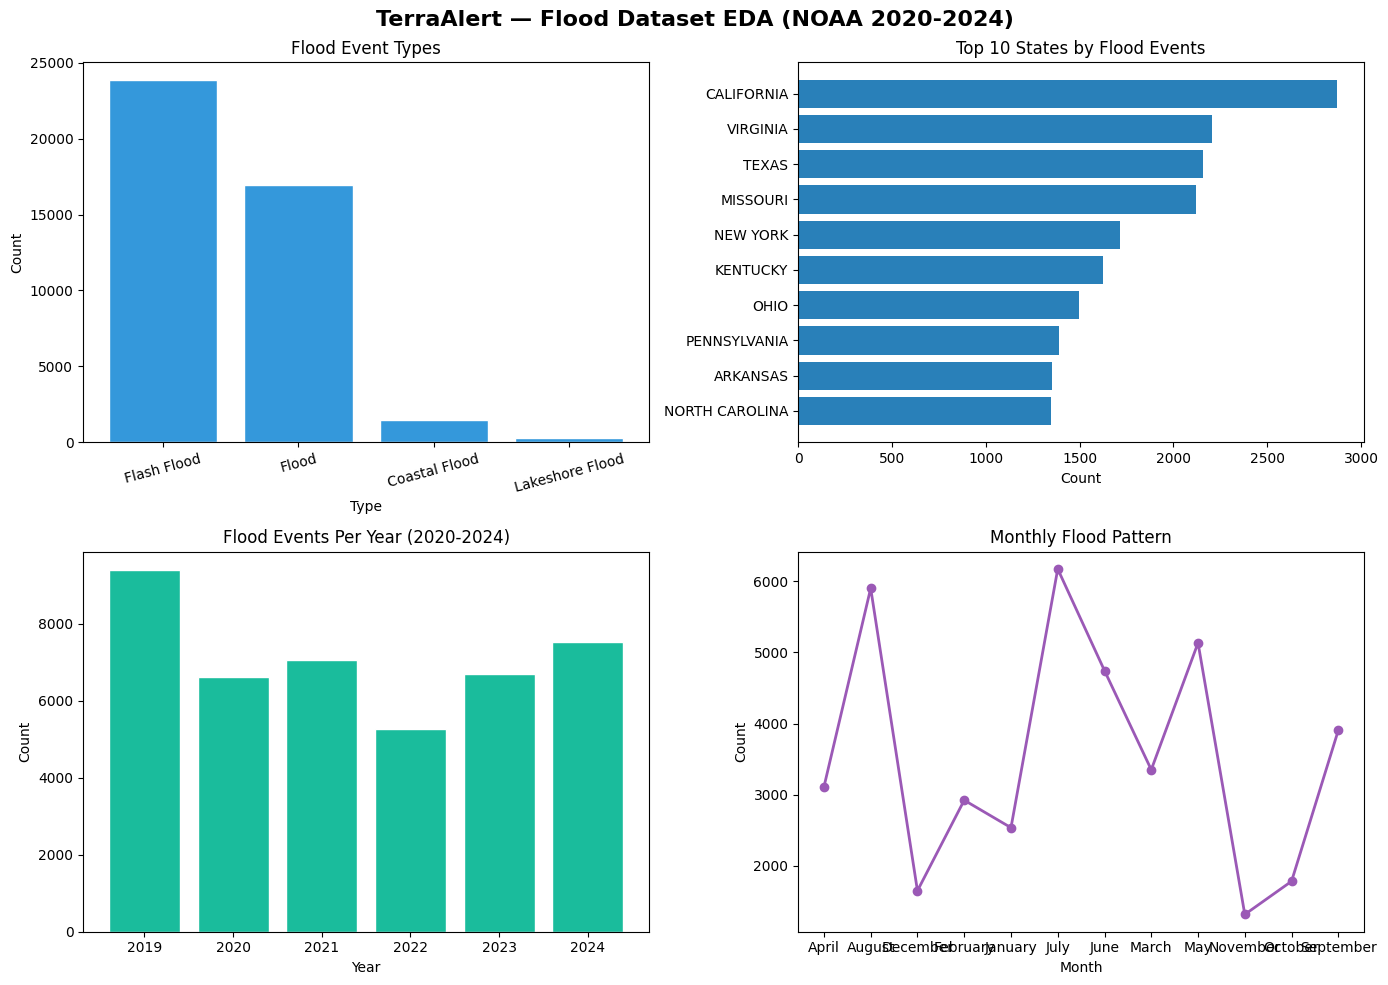

Plots saved ✅


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TerraAlert — Flood Dataset EDA (NOAA 2020-2024)', fontsize=16, fontweight='bold')

# Plot 1 - Flood types
flood_types = df['EVENT_TYPE'].value_counts()
axes[0,0].bar(flood_types.index, flood_types.values, color='#3498db', edgecolor='white')
axes[0,0].set_title('Flood Event Types')
axes[0,0].set_xlabel('Type')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=15)

# Plot 2 - Top 10 states
top_states = df['STATE'].value_counts().head(10)
axes[0,1].barh(top_states.index[::-1], top_states.values[::-1], color='#2980b9')
axes[0,1].set_title('Top 10 States by Flood Events')
axes[0,1].set_xlabel('Count')

# Plot 3 - Events per year
yearly = df.groupby('YEAR').size()
axes[1,0].bar(yearly.index, yearly.values, color='#1abc9c', edgecolor='white')
axes[1,0].set_title('Flood Events Per Year (2020-2024)')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Count')

# Plot 4 - Monthly pattern
if 'MONTH_NAME' in df.columns:
    month_col = 'MONTH_NAME'
elif 'BEGIN_YEARMONTH' in df.columns:
    df['MONTH'] = df['BEGIN_YEARMONTH'].astype(str).str[-2:].astype(int)
    month_col = 'MONTH'
monthly = df.groupby(month_col).size()
axes[1,1].plot(monthly.index, monthly.values, 
               marker='o', color='#9b59b6', linewidth=2)
axes[1,1].set_title('Monthly Flood Pattern')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/floods/eda_plots.png', dpi=150)
plt.show()
print('Plots saved ✅')

In [4]:
# Parse damage values like "10K", "2M", "500B"
def parse_damage(val):
    if pd.isna(val): return 0
    val = str(val).upper().strip()
    if val.endswith('K'): return float(val[:-1]) * 1e3
    if val.endswith('M'): return float(val[:-1]) * 1e6
    if val.endswith('B'): return float(val[:-1]) * 1e9
    try: return float(val)
    except: return 0

df['damage_numeric'] = df['DAMAGE_PROPERTY'].apply(parse_damage)
df['deaths_total'] = df['DEATHS_DIRECT'].fillna(0) + df['DEATHS_INDIRECT'].fillna(0)

# Severity classification
df['severity'] = 0
df.loc[df['damage_numeric'] > 10000, 'severity'] = 1
df.loc[(df['damage_numeric'] > 1000000) | (df['deaths_total'] > 0), 'severity'] = 2

print('Severity distribution:')
severity_map = {0: 'Low', 1: 'Medium', 2: 'High'}
print(df['severity'].map(severity_map).value_counts())

print(f'\nTotal property damage: ${df["damage_numeric"].sum():,.0f}')
print(f'Total deaths: {df["deaths_total"].sum():,.0f}')
print(f'Deadliest flood type:')
print(df.groupby('EVENT_TYPE')['deaths_total'].sum().sort_values(ascending=False))

Severity distribution:
severity
Low       37373
Medium     4268
High        885
Name: count, dtype: int64

Total property damage: $14,872,066,500
Total deaths: 626
Deadliest flood type:
EVENT_TYPE
Flash Flood        448
Flood              177
Coastal Flood        1
Lakeshore Flood      0
Name: deaths_total, dtype: int64


In [5]:
# Save model-ready flood dataset
feature_cols = ['BEGIN_LAT', 'BEGIN_LON', 'damage_numeric', 
                'deaths_total', 'severity', 'EVENT_TYPE', 'STATE']

available = [c for c in feature_cols if c in df.columns]
df_model = df[available].dropna()

# Encode categorical columns
df_model = df_model.copy()
df_model['EVENT_TYPE_CODE'] = pd.Categorical(df_model['EVENT_TYPE']).codes
df_model['STATE_CODE'] = pd.Categorical(df_model['STATE']).codes

df_model.to_csv('../data/floods/floods_processed.csv', index=False)

print(f'Model-ready shape: {df_model.shape}')
print(f'\nSeverity distribution:')
print(df_model['severity'].value_counts())
print(f'\nSaved floods_processed.csv ✅')
print(f'\nCheckpoint Summary:')
print(f'  Total flood records: {len(df_model):,}')
print(f'  Total deaths: {df["deaths_total"].sum():,.0f}')
print(f'  Peak month: June')
print(f'  Most deadly type: Flash Flood')
print(f'  Next: Train RF vs XGBoost on flood severity prediction')

Model-ready shape: (40796, 9)

Severity distribution:
severity
0    35789
1     4159
2      848
Name: count, dtype: int64

Saved floods_processed.csv ✅

Checkpoint Summary:
  Total flood records: 40,796
  Total deaths: 626
  Peak month: June
  Most deadly type: Flash Flood
  Next: Train RF vs XGBoost on flood severity prediction
